PROJECT OBJECTIVE: Company’s management requires an automation which can create a classifier capable of
determining a flower’s species from a photo
Steps and tasks:
1. Import the data. Analyse the dimensions of the data.
2. Preprocess the data.
3. Data visualisation:
• Display the images
• Display the labels
• Display images vs labels
• Apply different filters [ for example: blur, contour, edge detection, emboss, smooth etc.] on the images and
display the image.
4. Train tune and test AIML image classifier model using:
• Use your own designed CNN for training
• Use transferred learning models for training
• Compare the results from the above 2 steps along with your detailed observations.
5. Explain in depth your strategy to maintain and support the AIML image classifier after it in production.

In [2]:
#Mount your Google drive so you can read them easily
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import os
os.chdir('/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg')
os.getcwd()

'/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg'

In [4]:
# Ignore the warnings
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=FutureWarning)

In [79]:
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import h5py


#from tensorflow.keras.utils import np_utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD
#from tensorflow.keras.constraints import maxnorm
from PIL import Image
from PIL import ImageMath

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import confusion_matrix
import cv2

from google.colab.patches import cv2_imshow
import glob
from sklearn.utils import shuffle

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model

In [6]:
!pip install tflearn

     |████████████████████████████████| 112kB 7.9MB/s 
  Created wheel for tflearn: filename=tflearn-0.5.0-cp37-none-any.whl size=127300 sha256=23c53c908562cbdac454632f4f47a17772d0132d7e556eddb144c8d88fc222e0
  Stored in directory: /root/.cache/pip/wheels/31/d2/ed/fb9a0d301dd9586c11e9547120278e624227f22fd5f4baf744
Successfully built tflearn


**Question 1: Import the data. Analyse the dimensions of the data.**

In [7]:
#1.1 - Import Dataset
import tflearn.datasets.oxflower17 as oxflower17

Instructions for updating:
non-resource variables are not supported in the long term


In [8]:
X, y = oxflower17.load_data(one_hot=True)
#np.savez_compressed('oxflower17', X=X, Y=Y)

#data = np.load('oxflower17.npz')
#X = data['X']
#y = data['Y']

In [9]:
#Analyze the dimensions of data
print("Shape of X:",X.shape)
print("Shape of Y:", y.shape)

Shape of X: (1360, 224, 224, 3)
Shape of Y: (1360, 17)


In [11]:
img=cv2.imread('0/image_0003.jpg')

In [12]:
img.shape

(704, 500, 3)

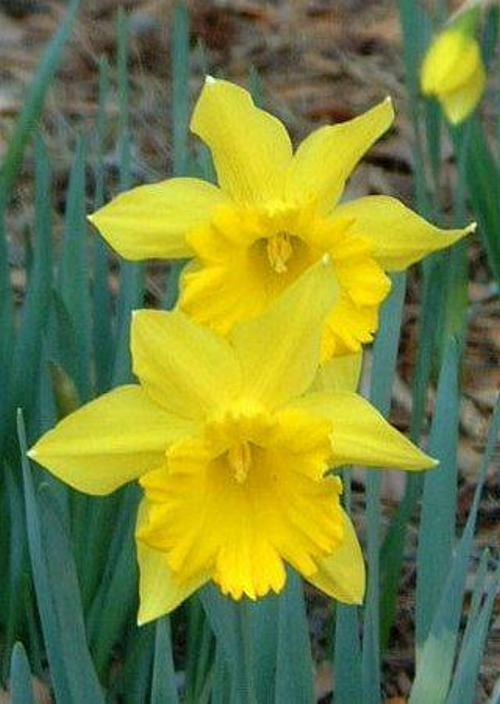

In [13]:
cv2_imshow(img)

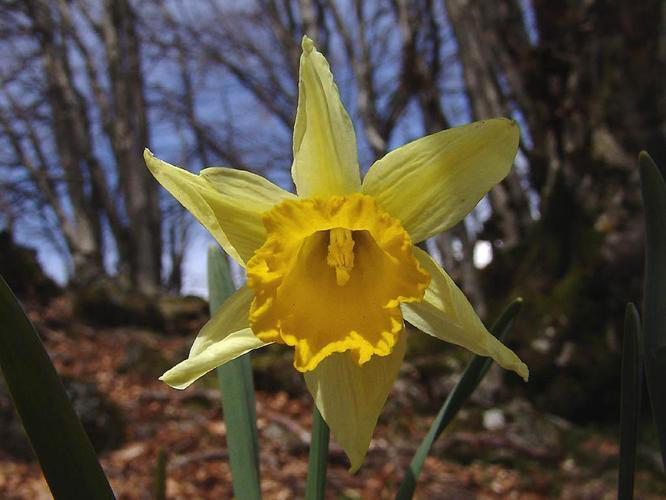

In [14]:
from PIL import Image #show one example of image
Image.open("/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg/0/image_0002.jpg")


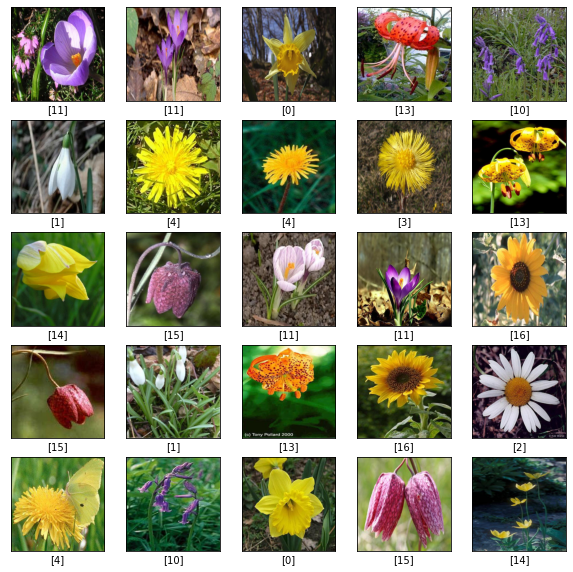

In [68]:
plt.figure(figsize=(10,10)) # plot 25 images
for i in range(25):
   plt.subplot(5,5,i+1)
   plt.xticks([])
   plt.yticks([])
   plt.grid(False)
   plt.imshow(Xtrain[i], cmap=plt.cm.binary)
   lbl= np.where(ytrain[i] == 1)
   plt.xlabel(lbl[0])

1.2 - **Analyse the dimensions of Image:**

In [11]:
images=[]
labels=[]
path='/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg'

for i in os.listdir(path):
  imgfiles = glob.glob(path+"/"+ i +"/image_*.jpg", recursive=True)
  for j in range(0, len(imgfiles)):
    img=cv2.imread(imgfiles[j])
    img=cv2.resize(img, (224,224))
    images.append(img)
    labels.append(i)

images = np.asarray(images)
labels = np.asarray(labels)

In [12]:
print('Size of oxflowers dataset Images:', len(images))

Size of oxflowers dataset Images: 1360


In [13]:
print('Size of oxflowers dataset Labels:', len(labels))

Size of oxflowers dataset Labels: 1360


In [14]:
print('Shape of images after resize:', images.shape)

Shape of images after resize: (1360, 224, 224, 3)


In [15]:
type(images), type(labels)

(numpy.ndarray, numpy.ndarray)

 **Question 2: Preprocess the data.**

When loading data through tflearn library, the dataset is encoded already to have image value between 0 and 1 and the labels are already one hot encoded.

Let's change the image to gray scale and view images.

In [90]:
import random
def show_image(img_data, labels):
    plt.figure(figsize=(10,10)) 
    for i in range(0, 25):
        n = random.randint(0,25)
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(img_data[n], cmap=plt.cm.binary)
        lbl = np.where(labels[n] == 1)
        plt.xlabel(lbl[0])

In [75]:
gray_img_data=[]
class_name=[]

for i in range(0, len(X)):
    image=cv2.cvtColor(X[i], cv2.COLOR_RGB2GRAY)
    gray_img_data.append(image)

gray_img_data = np.asarray(gray_img_data)

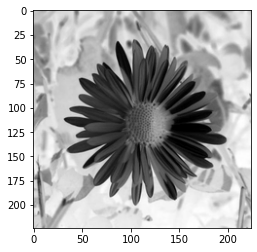

In [81]:
plt.imshow(gray_img_data[0], cmap=plt.cm.binary)

In [76]:
gray_img_data.shape

(1360, 224, 224)

In [72]:
#gray_img_data=np.reshape(gray_img_data, (len(gray_img_data),224,224,1))

Let's change the images from RGB to gray scale.

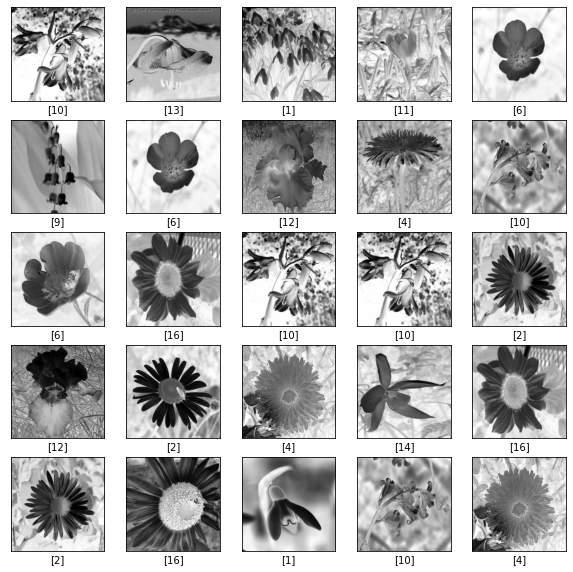

In [91]:
show_image(gray_img_data, y)

In [18]:
##Train / test split using data loaded through images from image folder.
#split train and test data into 70:30 ratio
Xtrain, Xtest, ytrain, ytest = train_test_split(images, labels, test_size=0.30, random_state=31)

In [28]:
#Train / test split using data loaded through tflearn library
#Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=31)

In [19]:
print("Shape of Xtrain:", Xtrain.shape)
print("Shape of Xtest:", Xtest.shape)
print("Shape of ytrain:", ytrain.shape)
print("Shape of ytest:", ytest.shape)

Shape of Xtrain: (952, 224, 224, 3)
Shape of Xtest: (408, 224, 224, 3)
Shape of ytrain: (952,)
Shape of ytest: (408,)


In [20]:
#Normalize the data by dividing by 255

Xtrain = Xtrain / 255.0
Xtest = Xtest / 255.0

In [22]:
#One hot encode the labels for train and test data
ytrain_cat = to_categorical(ytrain)
ytest_cat = to_categorical(ytest)

In [24]:
print("Shape of Xtrain:", Xtrain.shape)
print("Shape of Xtest:", Xtest.shape)
print("Shape of ytrain:", ytrain_cat.shape)
print("Shape of ytest:", ytest_cat.shape)

Shape of Xtrain: (952, 224, 224, 3)
Shape of Xtest: (408, 224, 224, 3)
Shape of ytrain cat: (952, 17)
Shape of ytest cat: (408, 17)


**Question 3: Data visualisation: • Display the images • Display the labels • Display images vs labels • Apply different filters [ for example: blur, contour, edge detection, emboss, smooth etc.] on the images and display the image.**

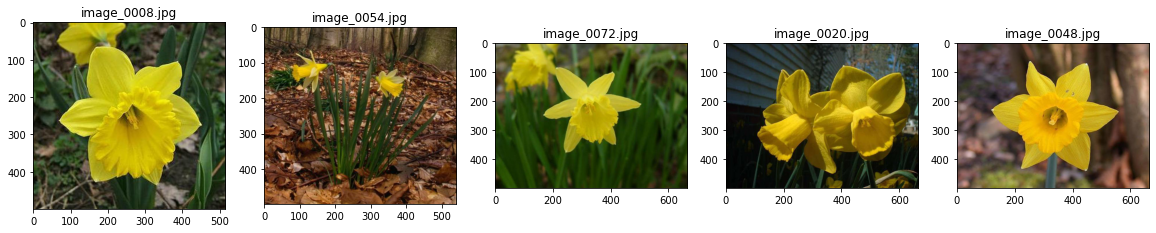

In [31]:
#3.1  Display the images

import random
import matplotlib.image as mpimg
plt.figure(figsize=(20,20))
img_folder=r'/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg/0/'
for i in range(5):
    file = random.choice(os.listdir(img_folder))
    image_path= os.path.join(img_folder, file)
    img=mpimg.imread(image_path)
    ax=plt.subplot(1,5,i+1)
    ax.title.set_text(file)
    plt.imshow(img)

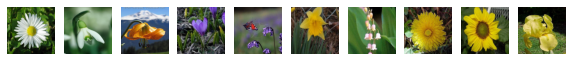

label for each of the above image: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [32]:
#3.2  Display the labels- visualizing the first 10 images in the dataset and their labels
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X[i], cmap=plt.cm.binary)
    plt.axis('off')
plt.show()
print('label for each of the above image: %s' % (ytrain[i]))

In [34]:
#3.3  Display images vs labels 
import random
def show_image(X, labels):
    plt.figure(figsize=(10,10)) 
    for i in range(25):
        n = random.randint(0,len(X))
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(X[n], cmap=plt.cm.binary)
        lbl = np.where(labels[n] == 1)
        plt.xlabel(lbl[0])

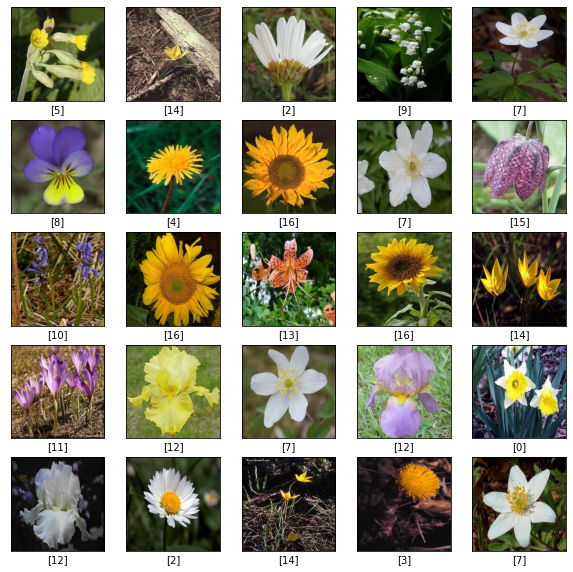

In [35]:
show_image(X, y)

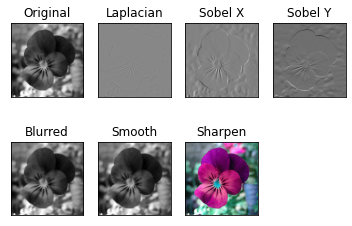

In [36]:
#3.4 Apply different filters [ for example: blur, contour, edge detection, emboss, smooth etc.] on the images and display the image.


img0 = cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg/16/image_1281.jpg',)

# converting to gray scale
gray = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)

# remove noise
cv_img = cv2.GaussianBlur(gray,(3,3),0)

#3.1 - Edge detection - Sobel and Laplacian filtering

laplacian = cv2.Laplacian(cv_img,cv2.CV_64F)
sobelx = cv2.Sobel(cv_img,cv2.CV_64F,1,0,ksize=5)  # x
sobely = cv2.Sobel(cv_img,cv2.CV_64F,0,1,ksize=5)  # y


#3.2 - Blur filtering
bilateral_blur = cv2.bilateralFilter(cv_img, 9, 75, 75)

#3.3 - Smooth Filtering - nothing but blur the image to get smooth effect.
GaussianBlur = cv2.GaussianBlur(cv_img,(9,9),0)

#3.4 - sharpen images - used to sharpen the colored images.
# Creating our sharpening filter
filter = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
sharp_img=cv2.filter2D(img0, -1, filter)

plt.subplot(2,4,1),plt.imshow(cv_img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(2,4,2),plt.imshow(laplacian,cmap = 'gray')
plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.subplot(2,4,3),plt.imshow(sobelx,cmap = 'gray')
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(2,4,4),plt.imshow(sobely,cmap = 'gray')
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])
plt.subplot(2,4,5), plt.imshow(bilateral_blur,cmap = 'gray')
plt.title('Blurred'),plt.xticks([]), plt.yticks([])
plt.subplot(2,4,6), plt.imshow(GaussianBlur,cmap = 'gray')
plt.title('Smooth'),plt.xticks([]), plt.yticks([])
plt.subplot(2,4,7), plt.imshow(sharp_img,cmap = 'gray')
plt.title('Sharpen'),plt.xticks([]), plt.yticks([])
plt.show()

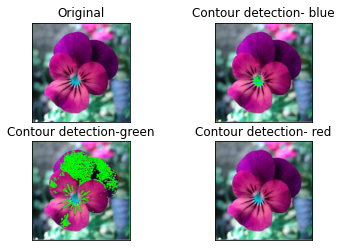

In [37]:
#3.5 - Find and draw contours on the image.
# read the image
image = cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg/16/image_1281.jpg',)
#image = cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg/3/image_0243.jpg',)
# B, G, R channel splitting
blue, green, red = cv2.split(image)

# detect contours using blue channel and without thresholding
contours1, hierarchy1 = cv2.findContours(image=blue, mode=cv2.RETR_TREE, method=cv2.CHAIN_APPROX_NONE)

# draw contours on the original image
image_contour_blue = image.copy()
cv2.drawContours(image=image_contour_blue, contours=contours1, contourIdx=-1, color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)
# see the results
#cv2.imshow('Contour detection using blue channels only', image_contour_blue)

plt.subplot(2,2,1),plt.imshow(image,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])

plt.subplot(2,2,2), plt.imshow(image_contour_blue)
plt.title('Contour detection- blue'),plt.xticks([]), plt.yticks([])
cv2.waitKey(0)
cv2.imwrite('blue_channel.jpg', image_contour_blue)
cv2.destroyAllWindows()

# detect contours using green channel and without thresholding
contours2, hierarchy2 = cv2.findContours(image=green, mode=cv2.RETR_TREE, method=cv2.CHAIN_APPROX_NONE)
# draw contours on the original image
image_contour_green = image.copy()
cv2.drawContours(image=image_contour_green, contours=contours2, contourIdx=-1, color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)

# see the results
#cv2.imshow('Contour detection-green channels', image_contour_green)

plt.subplot(2,2,3), plt.imshow(image_contour_green)
plt.title('Contour detection-green'),plt.xticks([]), plt.yticks([])
cv2.waitKey(0)
cv2.imwrite('green_channel.jpg', image_contour_green)
cv2.destroyAllWindows()

# detect contours using red channel and without thresholding
contours3, hierarchy3 = cv2.findContours(image=red, mode=cv2.RETR_TREE, method=cv2.CHAIN_APPROX_NONE)
# draw contours on the original image
image_contour_red = image.copy()
cv2.drawContours(image=image_contour_red, contours=contours3, contourIdx=-1, color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)
# see the results
#cv2.imshow('Contour detection using red channels only', image_contour_red)
plt.subplot(2,2,4), plt.imshow(image_contour_red)
plt.title('Contour detection- red'),plt.xticks([]), plt.yticks([])
cv2.waitKey(0)
cv2.imwrite('red_channel.jpg', image_contour_red)
cv2.destroyAllWindows()

(Text(0.5, 1.0, 'Emboss'),
 ([], <a list of 0 Text major ticklabel objects>),
 ([], <a list of 0 Text major ticklabel objects>))

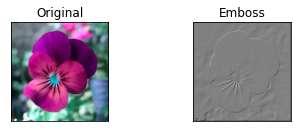

In [38]:
#3.6 - Emboss Filtering

def Filter_Fudiao(src_img):
    filter=np.array([[1,0],[0,-1]]) # will give emboss effects
    #filter = np.array([[-1, 0], [0, 1]])   #will give engraving filter effects
    row=src_img.shape[0]
    col=src_img.shape[1]
    new_img=np.zeros([row,col],dtype=np.uint8)
    for i in range(row-1):
        for j in range(col-1):
            new_value = np.sum(src_img[i:i + 2, j:j + 2] * filter) + 128  # point multiply
            if new_value > 255:
                new_value = 255
            elif new_value < 0:
                new_value = 0
            else:
                pass
            new_img[i, j]=new_value
    return new_img

src_img=cv2.imread('/content/gdrive/MyDrive/Colab Notebooks/CV with CNN/17flowers/jpg/16/image_1281.jpg',)
gray_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY)
new_img=Filter_Fudiao(gray_img)

plt.subplot(2,2,1),plt.imshow(src_img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])

plt.subplot(2,2,2),plt.imshow(new_img,cmap = 'gray')
plt.title('Emboss'), plt.xticks([]), plt.yticks([])

**Question 4: Train tune and test AIML image classifier model using: • Use your own designed CNN for training • Use transferred learning models for training • Compare the results from the above 2 steps along with your detailed observations.**

**4.1 - Train tune and test AIML image classifier model using your own designed CNN for training**

In [46]:
from tensorflow.keras import regularizers
#Build the model
tf.keras.backend.clear_session()
# Create the model 
model = Sequential()

#Layer 1 -conv2D
#kernel_regularizer=regularizers.l2(0.001)

model.add(Conv2D(32, kernel_size=(3,3), input_shape=(224, 224, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.001))

#Layer 2 - conv2D

model.add(Conv2D(64, (3,3), activation="relu")) #(3,3) = kernel_size=3 , 128 ==> filter_size
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.001))

#Layer 3 - conv2D

model.add(Conv2D(128, (3,3), activation="relu")) #(3,3) = kernel_size=3 , 128 ==> filter_size
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.001))

#Flatten
model.add(Flatten())

#Dense Layer 

model.add(Dense(100, kernel_initializer='he_normal', activation="relu"))
model.add(Dropout(0.001))

model.add(Dense(32, kernel_initializer='he_normal', activation="relu"))
model.add(Dropout(0.001))

model.add(Dense(17, activation="softmax"))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 222, 222, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 111, 111, 32)      0         
_________________________________________________________________
dropout (Dropout)            (None, 111, 111, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 109, 109, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 54, 54, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 54, 54, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 52, 52, 128)       7

In [47]:
#Compile the model
Adam=keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [48]:
#Evaluate the model
model_checkpoint = ModelCheckpoint('oxflower17.h5', save_best_only=True, monitor='val_acc', mode='max', verbose=1, save_freq='epoch')

callback= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

training_history = model.fit(Xtrain, ytrain_cat,
                    validation_data= (Xtest, ytest_cat),
                    batch_size=32, epochs = 100, 
                    verbose = 1,
                    callbacks=[callback,model_checkpoint])

Train on 952 samples, validate on 408 samples
Epoch 1/100
952/952 [==============================] - ETA: 0s - loss: 2.8164 - acc: 0.1061
Epoch 00001: val_acc improved from -inf to 0.09314, saving model to oxflower17.h5
952/952 [==============================] - 4s 4ms/sample - loss: 2.8164 - acc: 0.1061 - val_loss: 2.5724 - val_acc: 0.0931
Epoch 2/100
952/952 [==============================] - ETA: 0s - loss: 2.4384 - acc: 0.1775
Epoch 00002: val_acc improved from 0.09314 to 0.28922, saving model to oxflower17.h5
952/952 [==============================] - 3s 3ms/sample - loss: 2.4384 - acc: 0.1775 - val_loss: 2.0838 - val_acc: 0.2892
Epoch 3/100
952/952 [==============================] - ETA: 0s - loss: 1.8945 - acc: 0.3645
Epoch 00003: val_acc improved from 0.28922 to 0.36029, saving model to oxflower17.h5
952/952 [==============================] - 3s 3ms/sample - loss: 1.8945 - acc: 0.3645 - val_loss: 1.7251 - val_acc: 0.3603
Epoch 4/100
952/952 [==============================] - ET

In [49]:
print('Training score:', model.evaluate(Xtrain, ytrain_cat, batch_size=32))
print('Testing score:',model.evaluate(Xtest, ytest_cat, batch_size=32))

Training score: [0.6285558984059245, 0.8046219]
Testing score: [1.4523460140415267, 0.50735295]


4.2 -  Use transferred learning models for training.

In [50]:
tf.keras.backend.clear_session()
#Load the VGG model
vgg_conv = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in vgg_conv.layers:
    layer.trainable = False
 
for (i,layer) in enumerate(vgg_conv.layers):
    print(str(i) + " ", layer.trainable)

vgg_model = Sequential()
vgg_model.add(vgg_conv)

# Add new layers
vgg_model.add(Flatten())
vgg_model.add(Dense(256, activation='relu'))
vgg_model.add(Dropout(0.5))  ## try with .5 or .6

vgg_model.add(Dense(17, activation='softmax'))
vgg_model.summary()

58892288/58889256 [==============================] - 0s 0us/step
0  False
1  False
2  False
3  False
4  False
5  False
6  False
7  False
8  False
9  False
10  False
11  False
12  False
13  False
14  False
15  False
16  False
17  False
18  False
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten (Flatten)            (None, 25088)             0         
_________________________________________________________________
dense (Dense)                (None, 256)               6422784   
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 17)                4369      
Total par

In [51]:
from tensorflow.keras import optimizers

# compile the model (should be done *after* setting layers to non-trainable)
#vgg_model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


optimizers = tf.keras.optimizers.Adam(learning_rate=0.001)

#compile the model
vgg_model.compile(optimizer = optimizers, loss = 'categorical_crossentropy', metrics = ['accuracy'])

vgg_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten (Flatten)            (None, 25088)             0         
_________________________________________________________________
dense (Dense)                (None, 256)               6422784   
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 17)                4369      
Total params: 21,141,841
Trainable params: 6,427,153
Non-trainable params: 14,714,688
_________________________________________________________________


In [52]:
#vgg_model.fit(x=Xtrain, y=ytrain, batch_size=128, epochs=50 , verbose=1 )

#Evaluate the model
model_checkpoint = ModelCheckpoint('vgg16_oxflower17.h5', save_best_only=True, monitor='val_acc', mode='max', verbose=1, save_freq='epoch')

callback= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

vgg_history = vgg_model.fit(x=Xtrain, y=ytrain_cat,
                    validation_data= (Xtest, ytest_cat),
                    batch_size=32, epochs = 100, 
                    verbose = 1,
                    callbacks=[callback,model_checkpoint])

Train on 952 samples, validate on 408 samples
Epoch 1/100
952/952 [==============================] - ETA: 0s - loss: 3.4514 - acc: 0.1880
Epoch 00001: val_acc improved from -inf to 0.41422, saving model to vgg16_oxflower17.h5
952/952 [==============================] - 21s 22ms/sample - loss: 3.4514 - acc: 0.1880 - val_loss: 2.0091 - val_acc: 0.4142
Epoch 2/100
952/952 [==============================] - ETA: 0s - loss: 1.8587 - acc: 0.3939
Epoch 00002: val_acc improved from 0.41422 to 0.53431, saving model to vgg16_oxflower17.h5
952/952 [==============================] - 7s 8ms/sample - loss: 1.8587 - acc: 0.3939 - val_loss: 1.5126 - val_acc: 0.5343
Epoch 3/100
952/952 [==============================] - ETA: 0s - loss: 1.4814 - acc: 0.5189
Epoch 00003: val_acc improved from 0.53431 to 0.66422, saving model to vgg16_oxflower17.h5
952/952 [==============================] - 7s 7ms/sample - loss: 1.4814 - acc: 0.5189 - val_loss: 1.1643 - val_acc: 0.6642
Epoch 4/100
952/952 [================

In [54]:
print('Using TL - VGG Model Testing score:',vgg_model.evaluate(Xtest, ytest_cat,batch_size=32))

Using TL - VGG Model Testing score: [0.4142786930589115, 0.877451]


In [72]:
test_pred = np.argmax(vgg_model.predict(Xtest), axis=1)  # index of max value

In [75]:
ytest.shape, test_pred.shape

((408,), (408,))

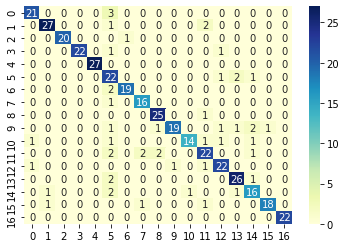

In [82]:
from sklearn.metrics import confusion_matrix
#confusion_matrix(ytest.astype(str), test_pred.astype(str))

sns.heatmap(confusion_matrix(ytest.astype(str), test_pred.astype(str)),annot=True,fmt='',cmap='YlGnBu')

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


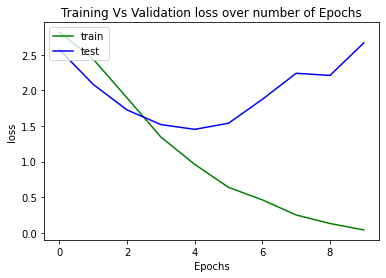

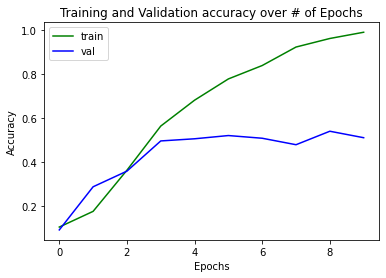

In [83]:
# list all data in history
print(training_history.history.keys())

# summarize history for loss
plt.plot(training_history.history['loss'],'g', label='Training loss' )
plt.plot(training_history.history['val_loss'], 'b', label='Validation loss')
plt.title('Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(training_history.history['acc'], 'g', label='Training accuracy')
plt.plot(training_history.history['val_acc'], 'b', label='validation accuracy')
plt.title('Training and Validation accuracy over # of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


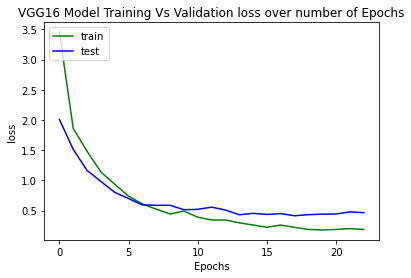

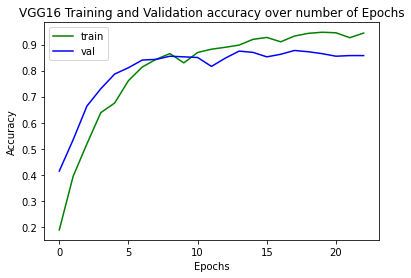

In [84]:
# list all data in history
print(training_history.history.keys())

# summarize history for loss
plt.plot(vgg_history.history['loss'],'g', label='Training loss' )
plt.plot(vgg_history.history['val_loss'], 'b', label='Validation loss')
plt.title('VGG16 Model Training Vs Validation loss over number of Epochs')
plt.ylabel('loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for accuracy
plt.plot(vgg_history.history['acc'], 'g', label='Training accuracy')
plt.plot(vgg_history.history['val_acc'], 'b', label='validation accuracy')
plt.title('VGG16 Training and Validation accuracy over number of Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

4.3 - Compare the results from the above 2 steps along with your detailed observations.

From the above graphs, my observation and findings are:

1. Accuracy - Keras model Vs VGG16 model.

In both Keras model and VGG16 model, The training accuracy (green color) increases significantly after 1 epoch and it gradually increases over number of Epochs increases. The Keras model has reached 100% accuracy whereas the VGG16 model reached ~100% of accuracy.

The Validation accuracy (blue color) gradually increases from 0 epoch to 4 epochs and keeps fluctuating and fits to 50%. The maximum accuracy is captured as ~50% whereas the VGG16 model reached 80% of accuracy.

2. Loss - Keras Vs VGG16 model.

In Keras model, the validation loss was high and fluctuates over number of epoch increase. Where as in VGG16 architecture, the loss decreases gradually and finally decreases to 0.5%


3. Keras Model.
This is the basic model built with convol2D layers and dense layers. Here I have started with initialising the model by specifying that the model is a sequential model. After initialising the model I add

1 x convolution layer of 32 channel of 3x3 kernal. 1 x maxpool layer of 2x2 pool size.
1 x convolution layer of 64 channel of 3x3 kernal. 1 x maxpool layer of 2x2 pool size.
1 x convolution layer of 128 channel of 3x3 kernal. 1 x maxpool layer of 2x2 pool size.

After creating all the convolution layer I pass the data to the dense layer so for that I flatten the vector which comes out of the convolutions and add

1 x Dense layer of 100 units
1 x Dense Layer of 32 units 
1 x Dense Layer of 17 units - Final layer units will match to the # of classes.

I used Linear, RELU activation in the 1st 2 dense layer of 1000 and 32 units respectively so that I stop forwarding negative values through the network. I use a 2 unit dense layer in the end with softmax activation as I have 2 classes to predict from in the end which are Mobile or No-Mobile. The softmax layer will output the value between 0 and 1 based on the confidence of the model that which class the images belongs to.


The built-in VGG16 architecture matches the input size of target oxflower dataset. Hence freeze the convnet layers and tune the dense layer and build a model.

After freezing the convnet Layer, i have following dense layer:

1 X dense layer with 256 units 
1 X dense layer with 17 units => number of classes.

With the VGG16 pre-trained model, gives a better accuracy of the classes.

**Question 5:  Explain in depth your strategy to maintain and support the AIML image classifier after it in production.**



In Support of AIML model in production, should follow like:

**1. Proactive Model Monitoring**

  1.1: Identify all the data samples which have at least one word not seen in the training data
  1.2: Identify all the data samples which are at least N-words longer or M words shorter than the average number of words in the training data

**2. Reactive Model Monitoring**

  2.1: Reactive model monitoring is quite similar to that of proactive model monitoring. But there are subtle differences in terms of the end goals. Whereas proactive model maintenance identified general patterns in the test data which are outliers compared to those in the training data, the goal of Reactive Model Maintenance is to identify what led to an erroneous output in a specific test sample and how it can be rectified.

**3. Address the Root Cause, Not the Symptoms**

  3.1: Given these wide varieties of sources that may lead to a drop in performance of the ML-systems over time and the intense pressure to fix the issues within a given SLA, it can be tempting to have a ‘thin-layer-of-rules’ which bypasses the ML machinery completely to address the immediate customer escalation.
  3.2: When the pre-defined ‘thickness’ is reached, our machine learning model has to be retrained to address the issues encoded in the thin-layer.
  3.3: Retraining a machine learning model that is already deployed in a live production environment is much easier said than done. For one, there are multiple ways to solve a particular data-driven problem, and as we see more data our choice of the model may change.


I am certain that data-driven technologies are the best solution to solve most of the problems that the tech world faces today. But, in the same breath, for these technologies to succeed, we need a holistic approach with the right expectations.


**4. Add Negative test data:**
  First, if possible add a low percentage of negative test data as part of model results. Negative testing is a method of testing an application that ensures that the model handles the unwanted input the way it should be.

**5. AutoEncoder Model:**
  Second, I would recommend developing an autoencoder (AE) model with training data our deployed model. I highly recommend developing this AE model before we deploy the model into production.

**6. Retrain the model with new data**

**7. Retrain the model with additional features**

**8. Develop a new model from scratch**


**Final thoughts**

·        How often we needed to validate the model is depends on the frequency of model consumed and the rate the base data will change over time. Understanding the business problem will help to determine the frequency of validating the model. When deploy the model, having a plan to validate the model will be good practice.

    Even though getting feedback directly from users and incorporate them into the model is great but in practice, getting timely feedback is hard and challenge to implement auto-tune the model. Try to find the model results from the business result, instance a call (call-turned-to-customer) success rate on recommendation model from the call history data than solely depend on the users’ feedback.

    In practice, ingesting negative test data into the model is not an option for many business problems. In those scenarios, the AE model and average accuracy score from the model in a specific period can be used to validate the effectiveness of the model.


References:
https://www.analyticsvidhya.com/blog/2019/10/deployed-machine-learning-model-post-production-monitoring/

https://www.datasciencecentral.com/profiles/blogs/how-to-maintain-model-effectiveness-after-deployed

